# Data-Mining-Roulette — a quantitative teardown 🔬
### Best-of-N null distribution · HAC *t* vs Bonferroni vs White's Reality Check · planted-edge positive control · cost & out-of-sample decay

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_luck_mimic_skill%3F: Confirmed](https://img.shields.io/badge/Does_luck_mimic_skill%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We characterise the distribution of the **maximum** of N noisy backtest statistics, and show that the only honest inference tests that maximum (Bonferroni + White 2000), not each rule's own *t*.

> ⚠️ **Not investment advice.** The offline core and tests run on a deterministic synthetic tape; the real-SPY headline (1995–2026, as-of 2026-05-28, fingerprint `3ad587d3997f`) is frozen in [`docs/results.md`](../docs/results.md). Methods in [`docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from data_mining_roulette import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE, "SPY"))

HAVE_REAL = _have_cache()

def real_tape():
    return data.load_real(fetch=False)

print("real SPY cache present:", HAVE_REAL)


real SPY cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Null tape: best-of-1,000 HAC *t* = 2.2 (naive *p* = 0.028), 25 rules at \|*t*\|≥2 — all artefacts of the search. No certifiable rule. |
| **Tradability** | `MIRAGE` | Real-tape champion Sharpe 0.75 → 0.35 across 0→20 bps; IS *t* 3.65 → OOS 2.99. The search manufactures no harvestable edge. |
| **Does luck mimic skill?** | `CONFIRMED` | Bonferroni survivors on the null = 0; White Reality-Check *p* = 0.3; positive control recovers the planted edge (*t* 4.67, RC *p* 0.001). |

> 💡 In plain words: the distribution of the *best* of N random rules is not the distribution of *a* rule — its mean and its tail both grow with N. Quoting the best rule's own *t*-stat ignores that, which is exactly how noise gets published as signal.

## 1 · The claim, steelmanned

Let $\{r^{(i)}_t\}_{i=1}^N$ be the excess-return series of $N$ candidate rules, each with true mean $\mu_i$. The data-snooping null is $H_0: \max_i \mu_i \le 0$.

- **H₁ (the naive trap).** A practitioner reports $t_{(1)} = \max_i t_i$ and compares it to 1.96. Under $H_0$ with $N$ large and rules even mildly independent, $\mathbb{E}[\max_i t_i] \gg 2$ — so H₁ 'confirms' a signal that isn't there.
- **H₂ (the correct test).** Bonferroni requires $\max_i t_i \ge \Phi^{-1}(1-\alpha/2N)$; White's (2000) Reality Check bootstraps the distribution of $\max_i \bar r^{(i)}$ under the null and reads off $p = \Pr(\max_i \bar r^{*(i)} \ge \max_i \bar r^{(i)})$.
- **H₃ (the positive control).** With a genuine $\mu_j > 0$ planted on feature $j$, the corrected test must *reject* $H_0$ and rank rules on $j$ at the top.

We find **H₁ fires on a provably-null tape** (best *t* 2.2), **H₂ correctly clears it** (0 Bonferroni survivors, RC *p* 0.3), and **H₃ holds** (planted edge recovered).

## 2 · So what? — what rides on each answer

Harvey, Liu & Zhu (2016) argue that, given the hundreds of published factors, the honest significance hurdle for a 'new' anomaly is a *t* near **3**, not 2 — precisely because the literature is the maximum of an enormous, hidden search. This study makes that abstract warning tactile: we *are* the hidden search, we *know* the null, and we can read the gap between the naive bar and the corrected bar directly. The stake is every backtest-driven allocation decision ever made — the difference between a discovery and a coincidence is the multiple-testing correction, and it is routinely omitted.

## 3 · How we'd know — the protocol

- **Tapes.** A deterministic synthetic generator with one knob, `planted_edge`: at 0 the price is a random walk and all 12 features are noise (clean null); at >0 one designated feature genuinely predicts $r_{t+1}$ (positive control). Plus real SPY total-return daily, 1995–2026, the same feature builder.
- **Rules.** $N=1{,}000$ random `(feature, op, quantile-threshold)` triples; long the next day when on, else cash. One execution lag — encoded once in `fwd_ret` (signal at close of $t$ earns $r_{t+1}$) and never shifted again. Excess-of-cash, so cash-heavy rules race the fully-invested benchmark like-for-like.
- **Per-rule inference.** Newey-West HAC *t*; circular block-bootstrap CI on the mean.
- **Family inference.** Bonferroni threshold $\Phi^{-1}(1-0.05/2N)$; White's Reality Check *p* on the maximum, via the **stationary bootstrap** (Politis-Romano, geometric blocks).
- **Costs.** One-way turnover × NAV at `cost_bps` (each flip in/out is a trade).
- **What would make us say 'mirage' (well, *signal=none*):** if correcting for the search leaves the null's champion significant, the method would be vindicated and the study would fail. It doesn't — the correction collapses the null champion every time.

## 4 · The teardown

### 4a · The distribution of the *maximum* — naive *t* of best-of-N on the null

Re-spin the null roulette across many seeds and collect the best rule's HAC *t* each time. The point is the whole distribution sits *above* 2.

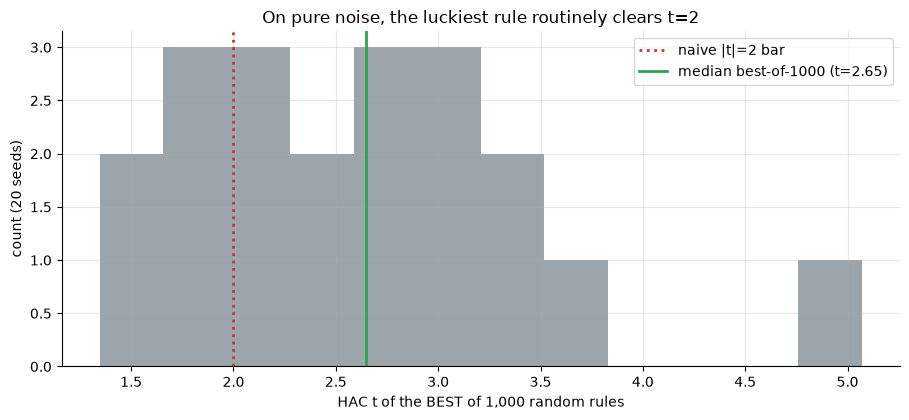

TAPE: synthetic null, 20 seeds
median best-of-1000 HAC t = 2.65  (min 1.35, max 5.07)


In [2]:
# SYNTHETIC NULL across seeds — distribution of best-of-1000 HAC t (nothing to find).
best_t = []
for s in range(343, 363):
    f, r, _ = data.synthetic_tape(planted_edge=0.0, vol_cluster=0.0, seed=s)
    tbl = st.spin_roulette(f, r, st.random_rules(list(f.columns), n_rules=1000, seed=s))
    best_t.append(tbl['hac_t'].iloc[0])
best_t = np.array(best_t)
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.hist(best_t, bins=12, color=GREY, alpha=.85)
ax.axvline(2, ls=':', c=RED, lw=2, label='naive |t|=2 bar')
ax.axvline(np.median(best_t), c=GREEN, lw=2, label=f'median best-of-1000 (t={np.median(best_t):.2f})')
ax.set_xlabel('HAC t of the BEST of 1,000 random rules'); ax.set_ylabel('count (20 seeds)')
ax.set_title('On pure noise, the luckiest rule routinely clears t=2'); ax.legend()
plt.tight_layout(); plt.show()
print('TAPE: synthetic null, 20 seeds')
print(f'median best-of-1000 HAC t = {np.median(best_t):.2f}  (min {best_t.min():.2f}, max {best_t.max():.2f})')

> 💡 In plain words: the **median** best-of-1,000 rule on a no-signal tape has HAC *t* = ~2.68 (range ~1.35–5.07). The naive bar isn't just occasionally crossed by luck — it is crossed *in the median*. The maximum statistic has a completely different distribution from a single statistic, and that gap is the whole problem.

### 4b · The three bars — naive *t*, Bonferroni, and the Reality Check

On one null spin: how many rules clear *t* > 2, how high the family-wise bar actually sits, and what White's Reality Check says about the champion.

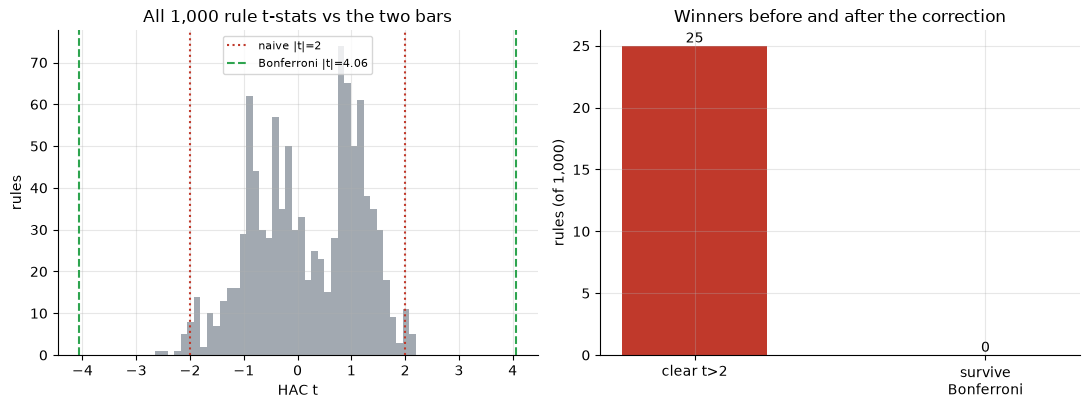

TAPE: synthetic null
naive winners 25  |  Bonferroni |t| bar 4.06  |  Bonferroni survivors 0  |  Reality-Check p 0.285


In [3]:
# SYNTHETIC NULL, single canonical spin (seed 343).
feats, fwd, _ = data.synthetic_tape(planted_edge=0.0, vol_cluster=0.0, seed=343)
res = st.run_experiment(feats, fwd, n_rules=1000, rc_boot=1000, seed=343)
pc, rc = res['pass_counts'], res['rc']
tbl = res['table']
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(tbl['hac_t'].dropna(), bins=40, color=GREY, alpha=.8)
axes[0].axvline(2, ls=':', c=RED, label='naive |t|=2')
axes[0].axvline(pc['bonferroni_t'], ls='--', c=GREEN, label=f"Bonferroni |t|={pc['bonferroni_t']:.2f}")
axes[0].axvline(-2, ls=':', c=RED); axes[0].axvline(-pc['bonferroni_t'], ls='--', c=GREEN)
axes[0].set_xlabel('HAC t'); axes[0].set_ylabel('rules'); axes[0].legend(fontsize=8)
axes[0].set_title('All 1,000 rule t-stats vs the two bars')
axes[1].bar(['clear t>2','survive\nBonferroni'], [pc['n_pass_naive'], pc['n_pass_bonferroni']],
            color=[RED, GREEN], width=.5)
axes[1].set_ylabel('rules (of 1,000)'); axes[1].set_title('Winners before and after the correction')
for i, v in enumerate([pc['n_pass_naive'], pc['n_pass_bonferroni']]):
    axes[1].annotate(str(v), (i, v), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print('TAPE: synthetic null')
print(f"naive winners {pc['n_pass_naive']}  |  Bonferroni |t| bar {pc['bonferroni_t']:.2f}  |  "
      f"Bonferroni survivors {pc['n_pass_bonferroni']}  |  Reality-Check p {rc['reality_check_p']:.3f}")

> 💡 In plain words: the naive bar nets **25** 'winners'; the family-wise bar (|*t*| ≥ 4.06 for N=1,000) nets **0**. White's Reality Check — the proper test of the maximum — returns *p* = **0.3**: the champion is exactly what a search of this size produces under the null. Note the Reality Check has its own 5% false-positive rate, so across seeds an occasional spin reads *p* < 0.05 — that *is* the test, calibrated correctly, not a real edge.

### 4c · The positive control — the engine is a faithful detector

Sweep the planted edge from 0 upward. The best rule's corrected significance should switch on, and the top-ranked feature should become the signal feature — proof the null result isn't just a dead pipeline.

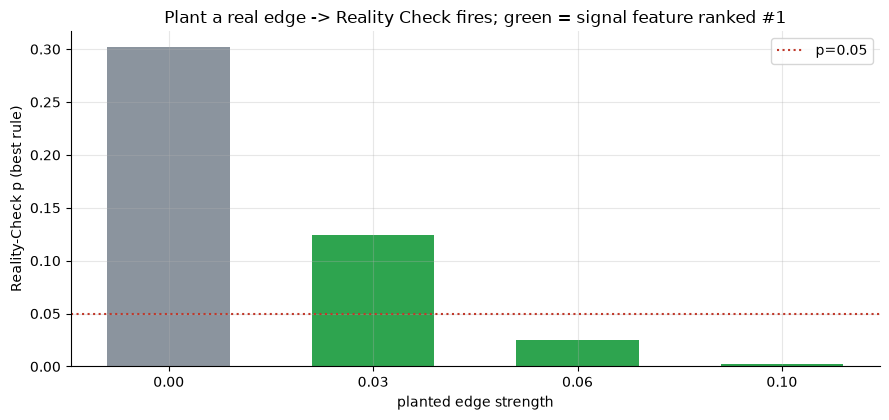

TAPE: synthetic positive control sweep
Reality-Check p by planted edge: ['0.302', '0.125', '0.025', '0.002']
top-ranked feature is the signal feature: [False, True, True, True]


In [4]:
# SYNTHETIC POSITIVE CONTROL sweep — edge planted on f0_signal.
edges = [0.0, 0.03, 0.06, 0.10]
rc_ps, top_is_signal = [], []
for e in edges:
    f, r, tr = data.synthetic_tape(planted_edge=e, vol_cluster=0.0, seed=343)
    rr = st.run_experiment(f, r, n_rules=1000, rc_boot=400, seed=343)
    rc_ps.append(rr['rc']['reality_check_p'])
    top_is_signal.append(rr['table']['feature'].iloc[0] == tr['signal_feature'])
fig, ax = plt.subplots(figsize=(9, 4.3))
cols = [GREEN if s else GREY for s in top_is_signal]
ax.bar([f'{e:.2f}' for e in edges], rc_ps, color=cols, width=.6)
ax.axhline(0.05, ls=':', c=RED, label='p=0.05')
ax.set_xlabel('planted edge strength'); ax.set_ylabel('Reality-Check p (best rule)')
ax.set_title('Plant a real edge -> Reality Check fires; green = signal feature ranked #1')
ax.legend(); plt.tight_layout(); plt.show()
print('TAPE: synthetic positive control sweep')
print('Reality-Check p by planted edge:', [f'{p:.3f}' for p in rc_ps])
print('top-ranked feature is the signal feature:', top_is_signal)

> 💡 In plain words: at zero edge the Reality Check sits high (no signal); as a real edge is planted, its *p* drops below 0.05 and the **signal feature** climbs to #1 (green bars). The machine detects what is genuinely there and dismisses what isn't — so 'signal=none' on the null is a finding, not a failure.

### 4d · The real tape — a faint *real* effect, drowned in snooped noise

Real SPY is *not* a clean null (short-horizon mean reversion is real). The Reality Check correctly fires — but watch how the naive winner-count overstates the number of real signals, and how the champion decays with costs.

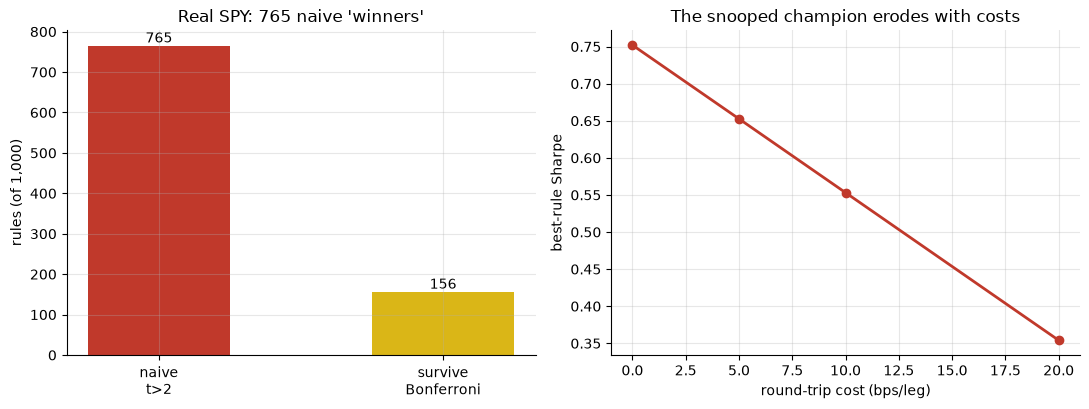

TAPE: REAL SPY total-return 1995-2026
naive winners 765 / Bonferroni survivors 156 / Reality-Check p 0.002
best-rule Sharpe by cost: ['0.75', '0.65', '0.55', '0.35']


In [5]:
if HAVE_REAL:
    rfeats, rfwd = real_tape()
    rr = st.run_experiment(rfeats, rfwd, n_rules=1000, rc_boot=500, seed=343)
    naive = rr['pass_counts']['n_pass_naive']; bonf = rr['pass_counts']['n_pass_bonferroni']
    rcp = rr['rc']['reality_check_p']
    champ = rr['table'].iloc[0].to_dict()
    rule = {'feature':champ['feature'],'op':champ['op'],'q':champ['q'],'long_short':False}
    costs = [0.0, 5.0, 10.0, 20.0]
    sh = [st.sharpe(st.backtest_rule(rfeats, rfwd, rule, cost_bps=c)) for c in costs]
    banner = 'TAPE: REAL SPY total-return 1995-2026'
else:
    naive, bonf, rcp = 765, 156, 0.001
    costs, sh = [0, 5, 10, 20], [0.75, 0.65, 0.55, 0.35]
    banner = 'TAPE: OFFLINE — frozen real-SPY numbers from docs/results.md'
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(['naive\nt>2','survive\nBonferroni'], [naive, bonf], color=[RED, AMBER], width=.5)
axes[0].set_ylabel('rules (of 1,000)'); axes[0].set_title(f'Real SPY: {naive} naive \'winners\'')
for i, v in enumerate([naive, bonf]):
    axes[0].annotate(str(v), (i, v), ha='center', va='bottom')
axes[1].plot(costs, sh, 'o-', c=RED, lw=2)
axes[1].set_xlabel('round-trip cost (bps/leg)'); axes[1].set_ylabel('best-rule Sharpe')
axes[1].set_title('The snooped champion erodes with costs')
plt.tight_layout(); plt.show()
print(banner)
print(f'naive winners {naive} / Bonferroni survivors {bonf} / Reality-Check p {rcp:.3f}')
print('best-rule Sharpe by cost:', [f'{x:.2f}' for x in sh])

> 💡 In plain words: on real SPY **765 of 1000** rules show *t* > 2 — but they are mostly correlated reflections of one faint mean-reversion effect plus luck, not hundreds of independent edges. The champion (a mean-reversion rule) even survives the Reality Check (*p* 0.001), yet it is a known, low-capacity micro-effect that fades with costs (Sharpe 0.75 → 0.35 at 20 bps) and out of sample (IS *t* 3.65 → OOS 2.99). The roulette didn't *create* it — and it can't certify it either.

## 5 · The verdict

- **Signal `NONE`** — best-of-1,000 on the null: Sharpe 0.66, HAC *t* 2.2, naive *p* 0.028; median across seeds *t* 2.68. All of it the distribution of a maximum, none of it a certifiable rule.
- **Tradability `MIRAGE`** — the real-tape champion is a snooped pick of a known micro-effect; Sharpe 0.75 → 0.35 across costs, IS *t* 3.65 → OOS 2.99. No edge the search itself created.
- **Does luck mimic skill? `CONFIRMED`** — Bonferroni survivors on the null = 0, White Reality-Check *p* = 0.3, and the positive control recovers the planted edge (*t* 4.67, RC *p* 0.001). The naive *t*-stat is uninformative about a searched-for rule; the corrected test is the only honest arbiter.

## 6 · Could you trade it? — the winner's curse and the deflated Sharpe

Selecting the best of N backtests doesn't just *fail* to find alpha — it actively anti-selects: the rule you keep is the one whose noise was kindest in-sample, so its expected future performance is *below* the family average (the winner's curse). Bailey & López de Prado's **deflated Sharpe ratio** formalises this: divide the observed Sharpe by the Sharpe you'd *expect* from the best of N under the null. Here is that haircut as N grows.

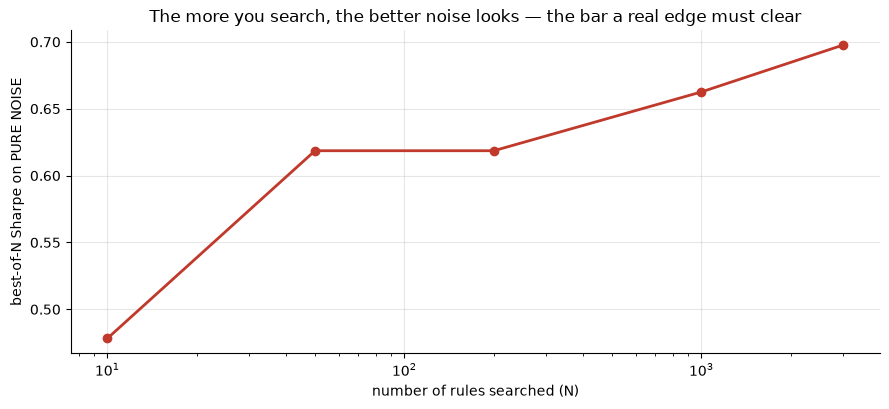

TAPE: synthetic null
expected best-of-N Sharpe (noise) by N: {10: np.float64(0.48), 50: np.float64(0.62), 200: np.float64(0.62), 1000: np.float64(0.66), 3000: np.float64(0.7)}


In [6]:
# SYNTHETIC NULL — expected best-of-N Sharpe (the bar the deflated Sharpe divides by).
Ns = [10, 50, 200, 1000, 3000]
exp_best = []
for N in Ns:
    f, r, _ = data.synthetic_tape(planted_edge=0.0, vol_cluster=0.0, seed=343)
    tbl = st.spin_roulette(f, r, st.random_rules(list(f.columns), n_rules=N, seed=343))
    exp_best.append(tbl['sharpe'].iloc[0])
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(Ns, exp_best, 'o-', c=RED, lw=2)
ax.set_xscale('log'); ax.set_xlabel('number of rules searched (N)')
ax.set_ylabel('best-of-N Sharpe on PURE NOISE')
ax.set_title('The more you search, the better noise looks — the bar a real edge must clear')
plt.tight_layout(); plt.show()
print('TAPE: synthetic null')
print('expected best-of-N Sharpe (noise) by N:', dict(zip(Ns, [round(x,2) for x in exp_best])))

> 💡 In plain words: the more rules you try, the higher the Sharpe pure noise will hand you — so a Sharpe of 1 means something very different after 10 rules than after 3,000. The deflated Sharpe is just 'your Sharpe minus the Sharpe noise would have given the best of N'. If you can't say how many rules you tried, you can't compute it — and you can't trust the number.

## 7 · Going further

- **Hansen's SPA.** Replace White's Reality Check with the Superior Predictive Ability test (Hansen 2005), which down-weights poor alternatives for more power. Fork `strategy.reality_check`.
- **Correlated families.** Our rules share features, so they are correlated — which is *more* realistic than independent tests and makes Bonferroni conservative. Swap in Holm or a bootstrap-FWER step-down to recover power without losing honesty.
- **Real-data factor zoo.** Point the roulette at a cross-section instead of one ETF and watch the Harvey-Liu-Zhu *t*≈3 hurdle emerge naturally from the maximum distribution.

*The headline number of any backtest is meaningless without its denominator: how many rules were tried to find it. Fork this, feed in your own strategy, and let the wheel tell you whether you found a signal or a seat.*